
# Spectral POD (SPOD) on a 3D Velocity Field — Manual Walkthrough (No SVD)

This notebook performs **SPOD** for a 3-component velocity field \((u,v,w)\) on your 15×15 masked grid, step-by-step (no `np.linalg.svd`).  
It also includes **blockwise temporal coefficients** and a **narrowband reconstruction** from the leading SPOD mode at a selected frequency.

---

## A quick note: what are the *singular values* (from the earlier POD notebook)?
Given the centered snapshot matrix \(X_c\) and its SVD \(X_c=U\Sigma V^\top\), the diagonal entries \(\sigma_i\) are **singular values**.  
Their squares \(\sigma_i^2\) are the eigenvalues of \(X_c X_c^\top\) and quantify the **variance/energy** captured by mode \(i\).  
Energy fraction is \(\sigma_i^2 / \sum_j \sigma_j^2\); units are (field units)\(^2\).



## 1) Load or synthesize velocity data and visualize

- Expected arrays: `u, v, w` with shape `(T, H, W)` and a boolean `mask` with shape `(H, W)`.
- If the NPZ file isn’t found, we *construct* a synthetic dataset inline.


NPZ not found, creating synthetic dataset inline…
T=512, grid=15x15, dt=0.02s


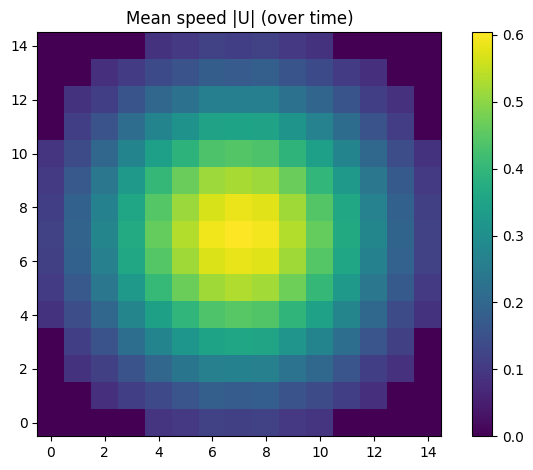

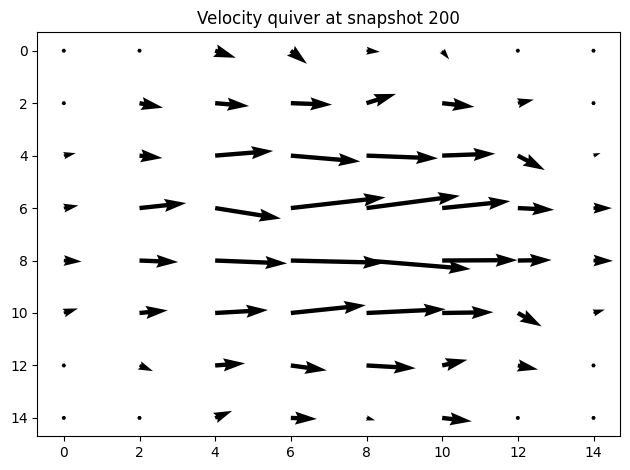

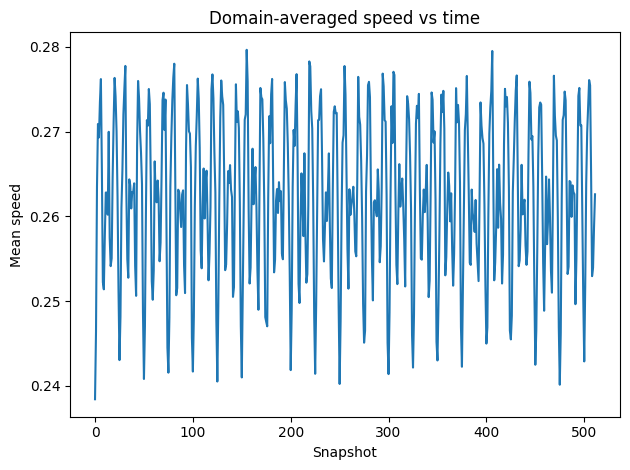

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Mask (same as your project)
mask = np.array([
[0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
], dtype=np.uint8).astype(bool)

H, W = mask.shape

# Try loading; otherwise synthesize inline
dt = 0.02
try:
    data = np.load('/mnt/data/synthetic_velocity3d_spod.npz')
    u, v, w = data['u'], data['v'], data['w']
    if 'dt' in data: dt = float(data['dt'])
    print("Loaded dataset from NPZ.")
except Exception as e:
    print("NPZ not found, creating synthetic dataset inline…")
    rng = np.random.default_rng(7)
    T = 512
    yy, xx = np.mgrid[0:H, 0:W]
    x = (xx - (W-1)/2)/((W-1)/2)
    y = (yy - (H-1)/2)/((H-1)/2)
    r2 = x**2 + y**2

    U0 = 0.6 * np.exp(-1.8*r2)  # mean x-flow
    f1, f2 = 2.0, 6.0           # Hz tones

    swirl_strength = np.exp(-2.0*r2)
    ux_swirl = -y * swirl_strength
    uy_swirl =  x * swirl_strength
    shear_shape = np.sin(2*np.pi*1.5*x) * np.exp(-1.0*r2)

    u = np.zeros((T, H, W)); v = np.zeros((T, H, W)); w = np.zeros((T, H, W))
    t = np.arange(T) * dt
    for k in range(T):
        s1 = np.sin(2*np.pi*f1*t[k])
        s2 = np.sin(2*np.pi*f2*t[k])
        u[k] = (U0 + 0.5*s1*ux_swirl + 0.2*s2*shear_shape) * mask + 0.03*rng.standard_normal((H,W))*mask
        v[k] = (0.5*s1*uy_swirl + 0.1*s2*shear_shape) * mask + 0.03*rng.standard_normal((H,W))*mask
        w[k] = (0.15*np.sin(2*np.pi*3.0*t[k]) * np.exp(-3.0*(r2-0.3)**2)) * mask + 0.02*rng.standard_normal((H,W))*mask

T = u.shape[0]
print(f"T={T}, grid={H}x{W}, dt={dt}s")

# Initial visuals
speed = np.sqrt(u**2 + v**2 + w**2)
mean_speed = speed.mean(axis=0)
plt.figure()
plt.imshow(mean_speed, origin='lower')
plt.colorbar()
plt.title("Mean speed |U| (over time)")
plt.tight_layout()
plt.show()

k = min(200, T-1)
step = 2
yy, xx = np.mgrid[0:H, 0:W]
plt.figure()
plt.quiver(xx[::step, ::step], yy[::step, ::step],
           u[k, ::step, ::step], v[k, ::step, ::step])
plt.title(f"Velocity quiver at snapshot {k}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(speed[:, mask].mean(axis=1))
plt.xlabel("Snapshot")
plt.ylabel("Mean speed")
plt.title("Domain-averaged speed vs time")
plt.tight_layout()
plt.show()


## 2) Helpers: stacking, windowing, and Welch FFT blocks


In [2]:
def stack_velocity(u, v, w, mask):
    '''Stack (u,v,w) into X of shape ((3*M) x T) using the same mask for all components.'''
    T, H, W = u.shape
    midx = mask
    M = int(midx.sum())
    X = np.zeros((3*M, T), dtype=float)
    X[0*M:1*M, :] = u[:, midx].T
    X[1*M:2*M, :] = v[:, midx].T
    X[2*M:3*M, :] = w[:, midx].T
    return X

def unstack_mode(phi, mask, H, W):
    '''Inverse of stack_velocity for a complex mode vector of size 3*M.'''
    midx = mask
    M = int(midx.sum())
    u_mode = np.zeros((H, W), dtype=complex)
    v_mode = np.zeros((H, W), dtype=complex)
    w_mode = np.zeros((H, W), dtype=complex)
    u_mode[midx] = phi[0*M:1*M]
    v_mode[midx] = phi[1*M:2*M]
    w_mode[midx] = phi[2*M:3*M]
    return u_mode, v_mode, w_mode

def welch_blocks(Xc, nfft, overlap, dt):
    '''Welch blocks with Hann window, rFFT along time.
       Returns Xhat_blocks: (K x dM x F), freqs, window, win_norm, hop, nfft'''
    dM, T = Xc.shape
    hop = int(nfft * (1 - overlap))
    assert hop > 0 and nfft <= T
    win = np.hanning(nfft)
    F = nfft//2 + 1
    blocks = []
    for t0 in range(0, T - nfft + 1, hop):
        seg = Xc[:, t0:t0+nfft] * win[None, :]
        Xhat = np.fft.rfft(seg, axis=1)  # (dM x F)
        blocks.append(Xhat)
    Xhat_blocks = np.stack(blocks, axis=0)  # (K x dM x F)
    freqs = np.fft.rfftfreq(nfft, d=dt)
    win_norm = (win**2).sum()
    return Xhat_blocks, freqs, win, win_norm, hop, nfft


## 3) SPOD core (snapshot method, weighted, no SVD)


Blocks K=7, dM=579, freq bins F=65


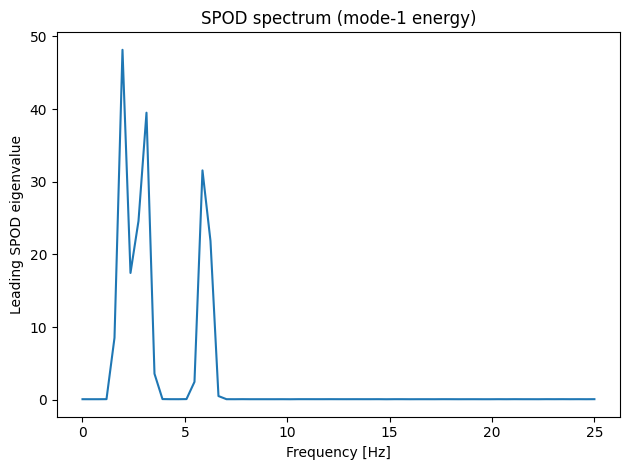

Peak frequency ~ 1.953125 Hz


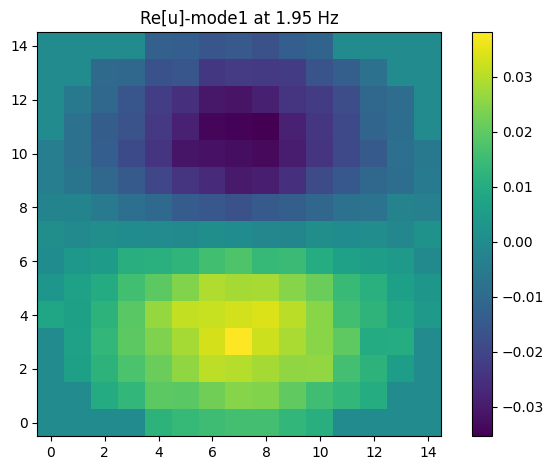

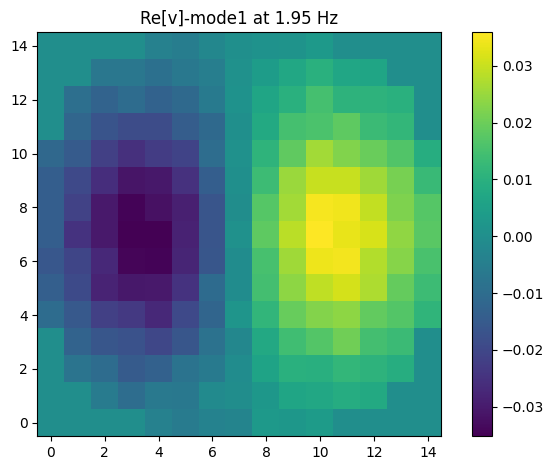

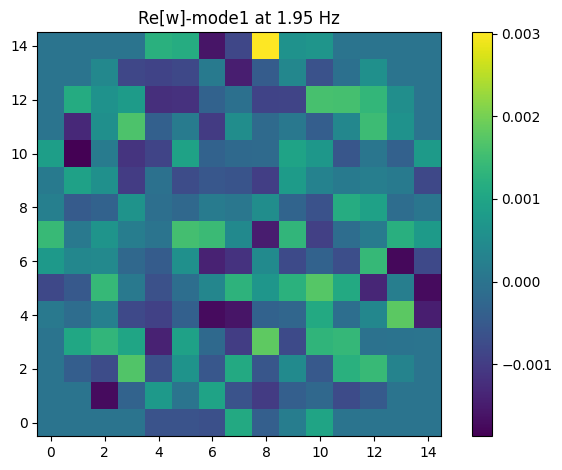

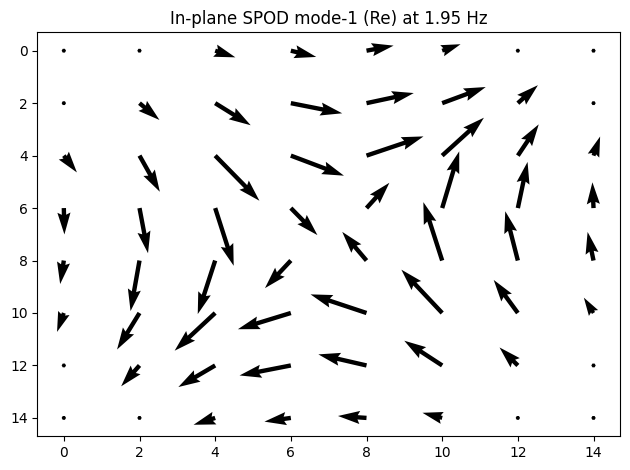

In [3]:
# Build centered data
X = stack_velocity(u, v, w, mask)             # (3*M x T)
mean = X.mean(axis=1, keepdims=True)
Xc = X - mean

# Weighting (kinetic-energy inner product). For uniform grid, W = I.
M = int(mask.sum())
w_cell = np.ones(M)
Wsqrt = np.sqrt(np.tile(w_cell, 3))  # (3*M,)

# Welch parameters
nfft = 128
overlap = 0.5

Xhat_blocks, freqs, win, win_norm, hop, nfft = welch_blocks(Xc, nfft=nfft, overlap=overlap, dt=dt)
K, dM, F = Xhat_blocks.shape
print(f"Blocks K={K}, dM={dM}, freq bins F={F}")

# Solve eigenproblem at each frequency (store top 3 modes)
nmodes_store = 3
evals_top = np.zeros((F, nmodes_store))
modes_top = np.zeros((F, dM, nmodes_store), dtype=complex)

for fi in range(F):
    # Y_f = W^{1/2} * Xhat_blocks(:,:,fi) / sqrt(win_norm)
    Yf = (Wsqrt[:, None] * Xhat_blocks[:, :, fi].T) / np.sqrt(win_norm)  # (3*M x K)

    # Snapshot cross-spectral density: C = (1/K) Y^* Y
    C = (Yf.conj().T @ Yf) / K   # (K x K), Hermitian

    lam, Alpha = np.linalg.eigh(C)  # ascending
    idx = np.argsort(lam)[::-1]
    lam = lam[idx]
    Alpha = Alpha[:, idx]

    for m in range(min(nmodes_store, len(lam))):
        if lam[m] <= 0:
            continue
        psi = (Yf @ Alpha[:, m]) / np.sqrt(K * lam[m])  # weighted mode
        phi = psi / Wsqrt                                # physical mode (3*M,)
        evals_top[fi, m] = lam[m]
        modes_top[fi, :, m] = phi

# Spectrum (leading eigenvalue)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(freqs, evals_top[:, 0])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Leading SPOD eigenvalue")
plt.title("SPOD spectrum (mode-1 energy)")
plt.tight_layout()
plt.show()

fi_peak = int(np.argmax(evals_top[:, 0]))
f_peak = freqs[fi_peak]
print("Peak frequency ~", f_peak, "Hz")

phi1 = modes_top[fi_peak, :, 0]
u_mode, v_mode, w_mode = unstack_mode(phi1, mask, H, W)

plt.figure(); plt.imshow(np.real(u_mode), origin='lower'); plt.colorbar(); plt.title(f"Re[u]-mode1 at {f_peak:.2f} Hz"); plt.tight_layout(); plt.show()
plt.figure(); plt.imshow(np.real(v_mode), origin='lower'); plt.colorbar(); plt.title(f"Re[v]-mode1 at {f_peak:.2f} Hz"); plt.tight_layout(); plt.show()
plt.figure(); plt.imshow(np.real(w_mode), origin='lower'); plt.colorbar(); plt.title(f"Re[w]-mode1 at {f_peak:.2f} Hz"); plt.tight_layout(); plt.show()

step = 2
yy, xx = np.mgrid[0:H, 0:W]
plt.figure()
plt.quiver(xx[::step, ::step], yy[::step, ::step],
           np.real(u_mode)[::step, ::step], np.real(v_mode)[::step, ::step])
plt.title(f"In-plane SPOD mode-1 (Re) at {f_peak:.2f} Hz")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4) Blockwise temporal coefficients and narrowband reconstruction


Mode consistency (||psi - Wsqrt*phi||): 0.0
Coefficient consistency (L2): 27.51124977533602


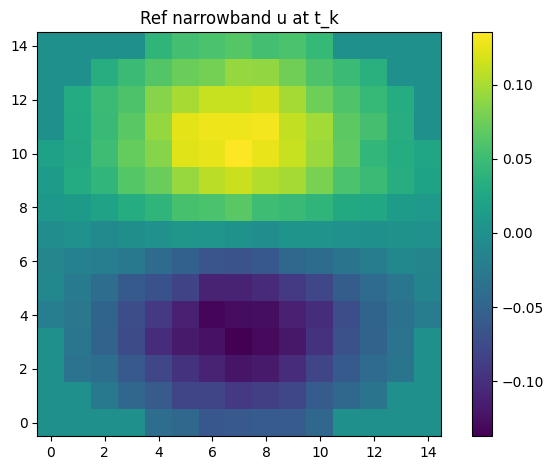

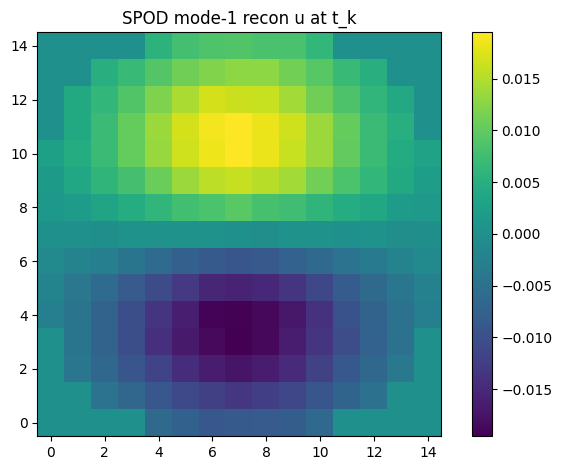

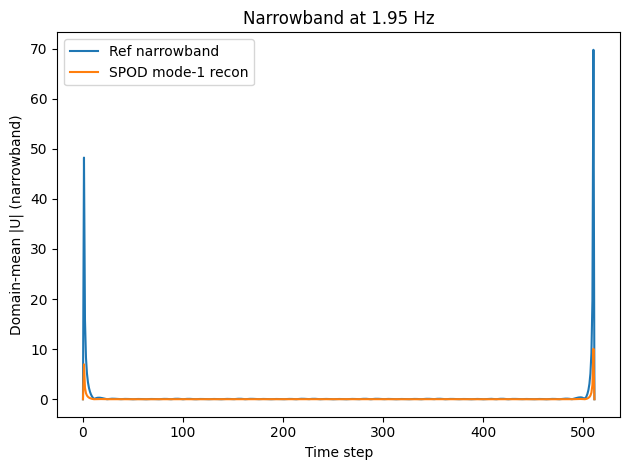

In [5]:

# --- Choose frequency (peak) and leading mode ---
fi_sel = fi_peak
phi = modes_top[fi_sel, :, 0]  # (3*M,)
F = nfft//2 + 1

# Recompute Y_f and eigenpairs for the selected frequency to get Alpha, lambda
Yf = (Wsqrt[:, None] * Xhat_blocks[:, :, fi_sel].T) / np.sqrt(win_norm)  # (3*M x K)
C = (Yf.conj().T @ Yf) / K
lam, Alpha = np.linalg.eigh(C)
idx = np.argsort(lam)[::-1]
lam = lam[idx]
Alpha = Alpha[:, idx]

lam1 = lam[0]
alpha1 = Alpha[:, 0]
psi = (Yf @ alpha1) / np.sqrt(K * lam1)   # weighted mode
# Sanity: psi vs Wsqrt*phi
print("Mode consistency (||psi - Wsqrt*phi||):", np.linalg.norm(psi - Wsqrt*phi))

# 1) Coefficients via eigenvector
c_via_alpha = np.sqrt(K*lam1) * alpha1   # (K,)

# 2) Coefficients via direct projection (one per block)
a_proj = np.zeros(K, dtype=complex)
for b in range(K):
    yb = Yf[:, b]                        # = W^{1/2} Xhat_b(fi)/sqrt(win_norm)
    a_proj[b] = np.vdot(psi, yb)         # psi^H yb

print("Coefficient consistency (L2):", np.linalg.norm(c_via_alpha - a_proj))

# --- Narrowband reconstruction via overlap-add ---
dM = X.shape[0]
Xrec = np.zeros((dM, X.shape[1]), dtype=float)    # time domain reconstruction
weight = np.zeros(X.shape[1], dtype=float)        # for window normalization

hop = int(nfft * (1 - overlap))
win = np.hanning(nfft)
F = nfft//2 + 1

for bi, t0 in enumerate(range(0, X.shape[1] - nfft + 1, hop)):
    # Only one frequency bin (fi_sel) retained
    Xhat_rec = np.zeros((dM, F), dtype=complex)
    Xhat_rec[:, fi_sel] = phi * a_proj[bi]        # (3*M,) * scalar

    # iFFT to time segment; note rFFT shape conventions
    seg_rec = np.fft.irfft(Xhat_rec, n=nfft, axis=1)  # (dM x nfft)

    # Apply same window and overlap-add
    seg_rec_win = seg_rec * win[None, :]
    Xrec[:, t0:t0+nfft] += seg_rec_win
    weight[t0:t0+nfft] += win**2

# Normalize where weight>0
valid = weight > 1e-12
Xrec[:, valid] /= weight[valid]

# --- Reference narrowband by keeping original content at fi_sel only (overlap-add) ---
Xbp = np.zeros_like(Xrec)
for bi, t0 in enumerate(range(0, X.shape[1] - nfft + 1, hop)):
    Xhat_bp = np.zeros((dM, F), dtype=complex)
    Xhat_bp[:, fi_sel] = Xhat_blocks[bi, :, fi_sel]  # keep full content at fi_sel
    seg_bp = np.fft.irfft(Xhat_bp, n=nfft, axis=1)
    seg_bp_win = seg_bp * win[None, :]
    Xbp[:, t0:t0+nfft] += seg_bp_win

Xbp[:, valid] /= weight[valid]

# Unstack to fields for a snapshot
def unstack_field(vec, mask, H, W):
    midx = mask
    M = int(midx.sum())
    a = np.zeros((H, W)); b = np.zeros((H, W)); c = np.zeros((H, W))
    a[midx] = vec[0*M:1*M]
    b[midx] = vec[1*M:2*M]
    c[midx] = vec[2*M:3*M]
    return a, b, c

k_show = min(220, X.shape[1]-1)
ua, va, wa = unstack_field(Xbp[:, k_show], mask, H, W)  # reference
ur, vr, wr = unstack_field(Xrec[:, k_show], mask, H, W) # SPOD recon

import matplotlib.pyplot as plt
plt.figure(); plt.imshow(ua, origin='lower'); plt.colorbar(); plt.title("Ref narrowband u at t_k"); plt.tight_layout(); plt.show()
plt.figure(); plt.imshow(ur, origin='lower'); plt.colorbar(); plt.title("SPOD mode-1 recon u at t_k"); plt.tight_layout(); plt.show()

# Time traces: domain-mean |U| for narrowband signals
def mean_speed_from_X(Xt, mask, H, W):
    M = int(mask.sum())
    u = Xt[0*M:1*M, :]
    v = Xt[1*M:2*M, :]
    w = Xt[2*M:3*M, :]
    out = np.zeros(Xt.shape[1])
    for n in range(Xt.shape[1]):
        uu = np.zeros((H,W)); vv = np.zeros((H,W)); ww = np.zeros((H,W))
        uu[mask] = u[:, n]; vv[mask] = v[:, n]; ww[mask] = w[:, n]
        out[n] = np.sqrt(uu**2 + vv**2 + ww**2)[mask].mean()
    return out

ms_rec = mean_speed_from_X(Xrec, mask, H, W)
ms_ref = mean_speed_from_X(Xbp, mask, H, W)

plt.figure()
plt.plot(ms_ref, label="Ref narrowband")
plt.plot(ms_rec, label="SPOD mode-1 recon")
plt.xlabel("Time step")
plt.ylabel("Domain-mean |U| (narrowband)")
plt.title(f"Narrowband at {freqs[fi_sel]:.2f} Hz")
plt.legend()
plt.tight_layout()
plt.show()



## 5) Notes
- Coefficients via eigenvector `sqrt(K·λ)·α` **match** direct projections onto the weighted mode.
- The reconstruction uses the **same Hann window and overlap-add** as the analysis; it visualizes what one SPOD mode contributes at a chosen frequency.
- For kinetic-energy optimality on non-uniform grids, set `w_cell = ρ·ΔV` per valid cell and repeat for \(u,v,w\) in `Wsqrt`.
- To reconstruct a **multi-mode** or **band** of frequencies, sum contributions over modes/frequency bins before the iFFT.
